# Preprocessing steps for each kind of algorithm

In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.impute import SimpleImputer

import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parents[1]))  # workaround to resolve my helper module above
from modules.plotting import *

DATA_PATH = "./data/"
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

## Preprocessing for Trees

In [2]:
train = pl.read_csv(DATA_PATH + "train.csv")
train.schema

Schema([('id', Int64),
        ('plate_thickness', Float64),
        ('plate_length', Float64),
        ('min_luminosity', Float64),
        ('defect_area', Float64),
        ('brightness_index', Float64),
        ('edge_index', Float64),
        ('square_index', Float64),
        ('total_luminosity', Float64),
        ('cooling_rate', Float64),
        ('processing_time', Float64),
        ('temperature', Float64),
        ('quality_score', Float64),
        ('production_date', String),
        ('production_time', String),
        ('operator_id', Int64),
        ('machine_id', String)])

In [3]:
train.null_count()

id,plate_thickness,plate_length,min_luminosity,defect_area,brightness_index,edge_index,square_index,total_luminosity,cooling_rate,processing_time,temperature,quality_score,production_date,production_time,operator_id,machine_id
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
prods = train.with_columns(
    pl.col("production_time").str.extract(r"^(\d{2})", 1).cast(pl.Int8).alias("hour")
)

prods = prods.with_columns([
    pl.col("production_date").str.strptime(pl.Date, "%Y-%m-%d")
])

prods = prods.with_columns([
    pl.col("production_date").dt.month().alias("month"),
    pl.col("production_date").dt.day().alias("day")
])

prods = prods.drop("production_date", "production_time", "id")

train_for_eng = prods.with_columns(
    (pl.col("total_luminosity") - pl.col("min_luminosity")).alias("delta_luminosity")
)

train_for_eng = train_for_eng.with_columns(
    (pl.col("plate_thickness") * pl.col("plate_length")).alias("volume_proxy")
)

train_for_eng = train_for_eng.with_columns(
    (pl.col("volume_proxy") / pl.col("processing_time")).alias("processing_efficiency")
)

train_for_eng = train_for_eng.with_columns(
    (pl.col("defect_area") / pl.col("volume_proxy")).alias("defect_proportion")
)

train_for_eng = train_for_eng.with_columns(
    (pl.col("square_index") * pl.col("edge_index")).alias("geometry_score")
)

train_for_eng = train_for_eng.with_columns(
    (pl.col("temperature") / pl.col("cooling_rate")).alias("cooling_difficulty")
)

train_for_eng = train_for_eng.with_columns(
    (pl.col("brightness_index") * pl.col("volume_proxy")).alias("brightness_times_volume")
)

In [12]:
train_for_eng.schema

Schema([('plate_thickness', Float64),
        ('plate_length', Float64),
        ('min_luminosity', Float64),
        ('defect_area', Float64),
        ('brightness_index', Float64),
        ('edge_index', Float64),
        ('square_index', Float64),
        ('total_luminosity', Float64),
        ('cooling_rate', Float64),
        ('processing_time', Float64),
        ('temperature', Float64),
        ('quality_score', Float64),
        ('operator_id', Int64),
        ('machine_id', String),
        ('hour', Int8),
        ('month', Int8),
        ('day', Int8),
        ('delta_luminosity', Float64),
        ('volume_proxy', Float64),
        ('processing_efficiency', Float64),
        ('defect_proportion', Float64),
        ('geometry_score', Float64),
        ('cooling_difficulty', Float64),
        ('brightness_times_volume', Float64)])

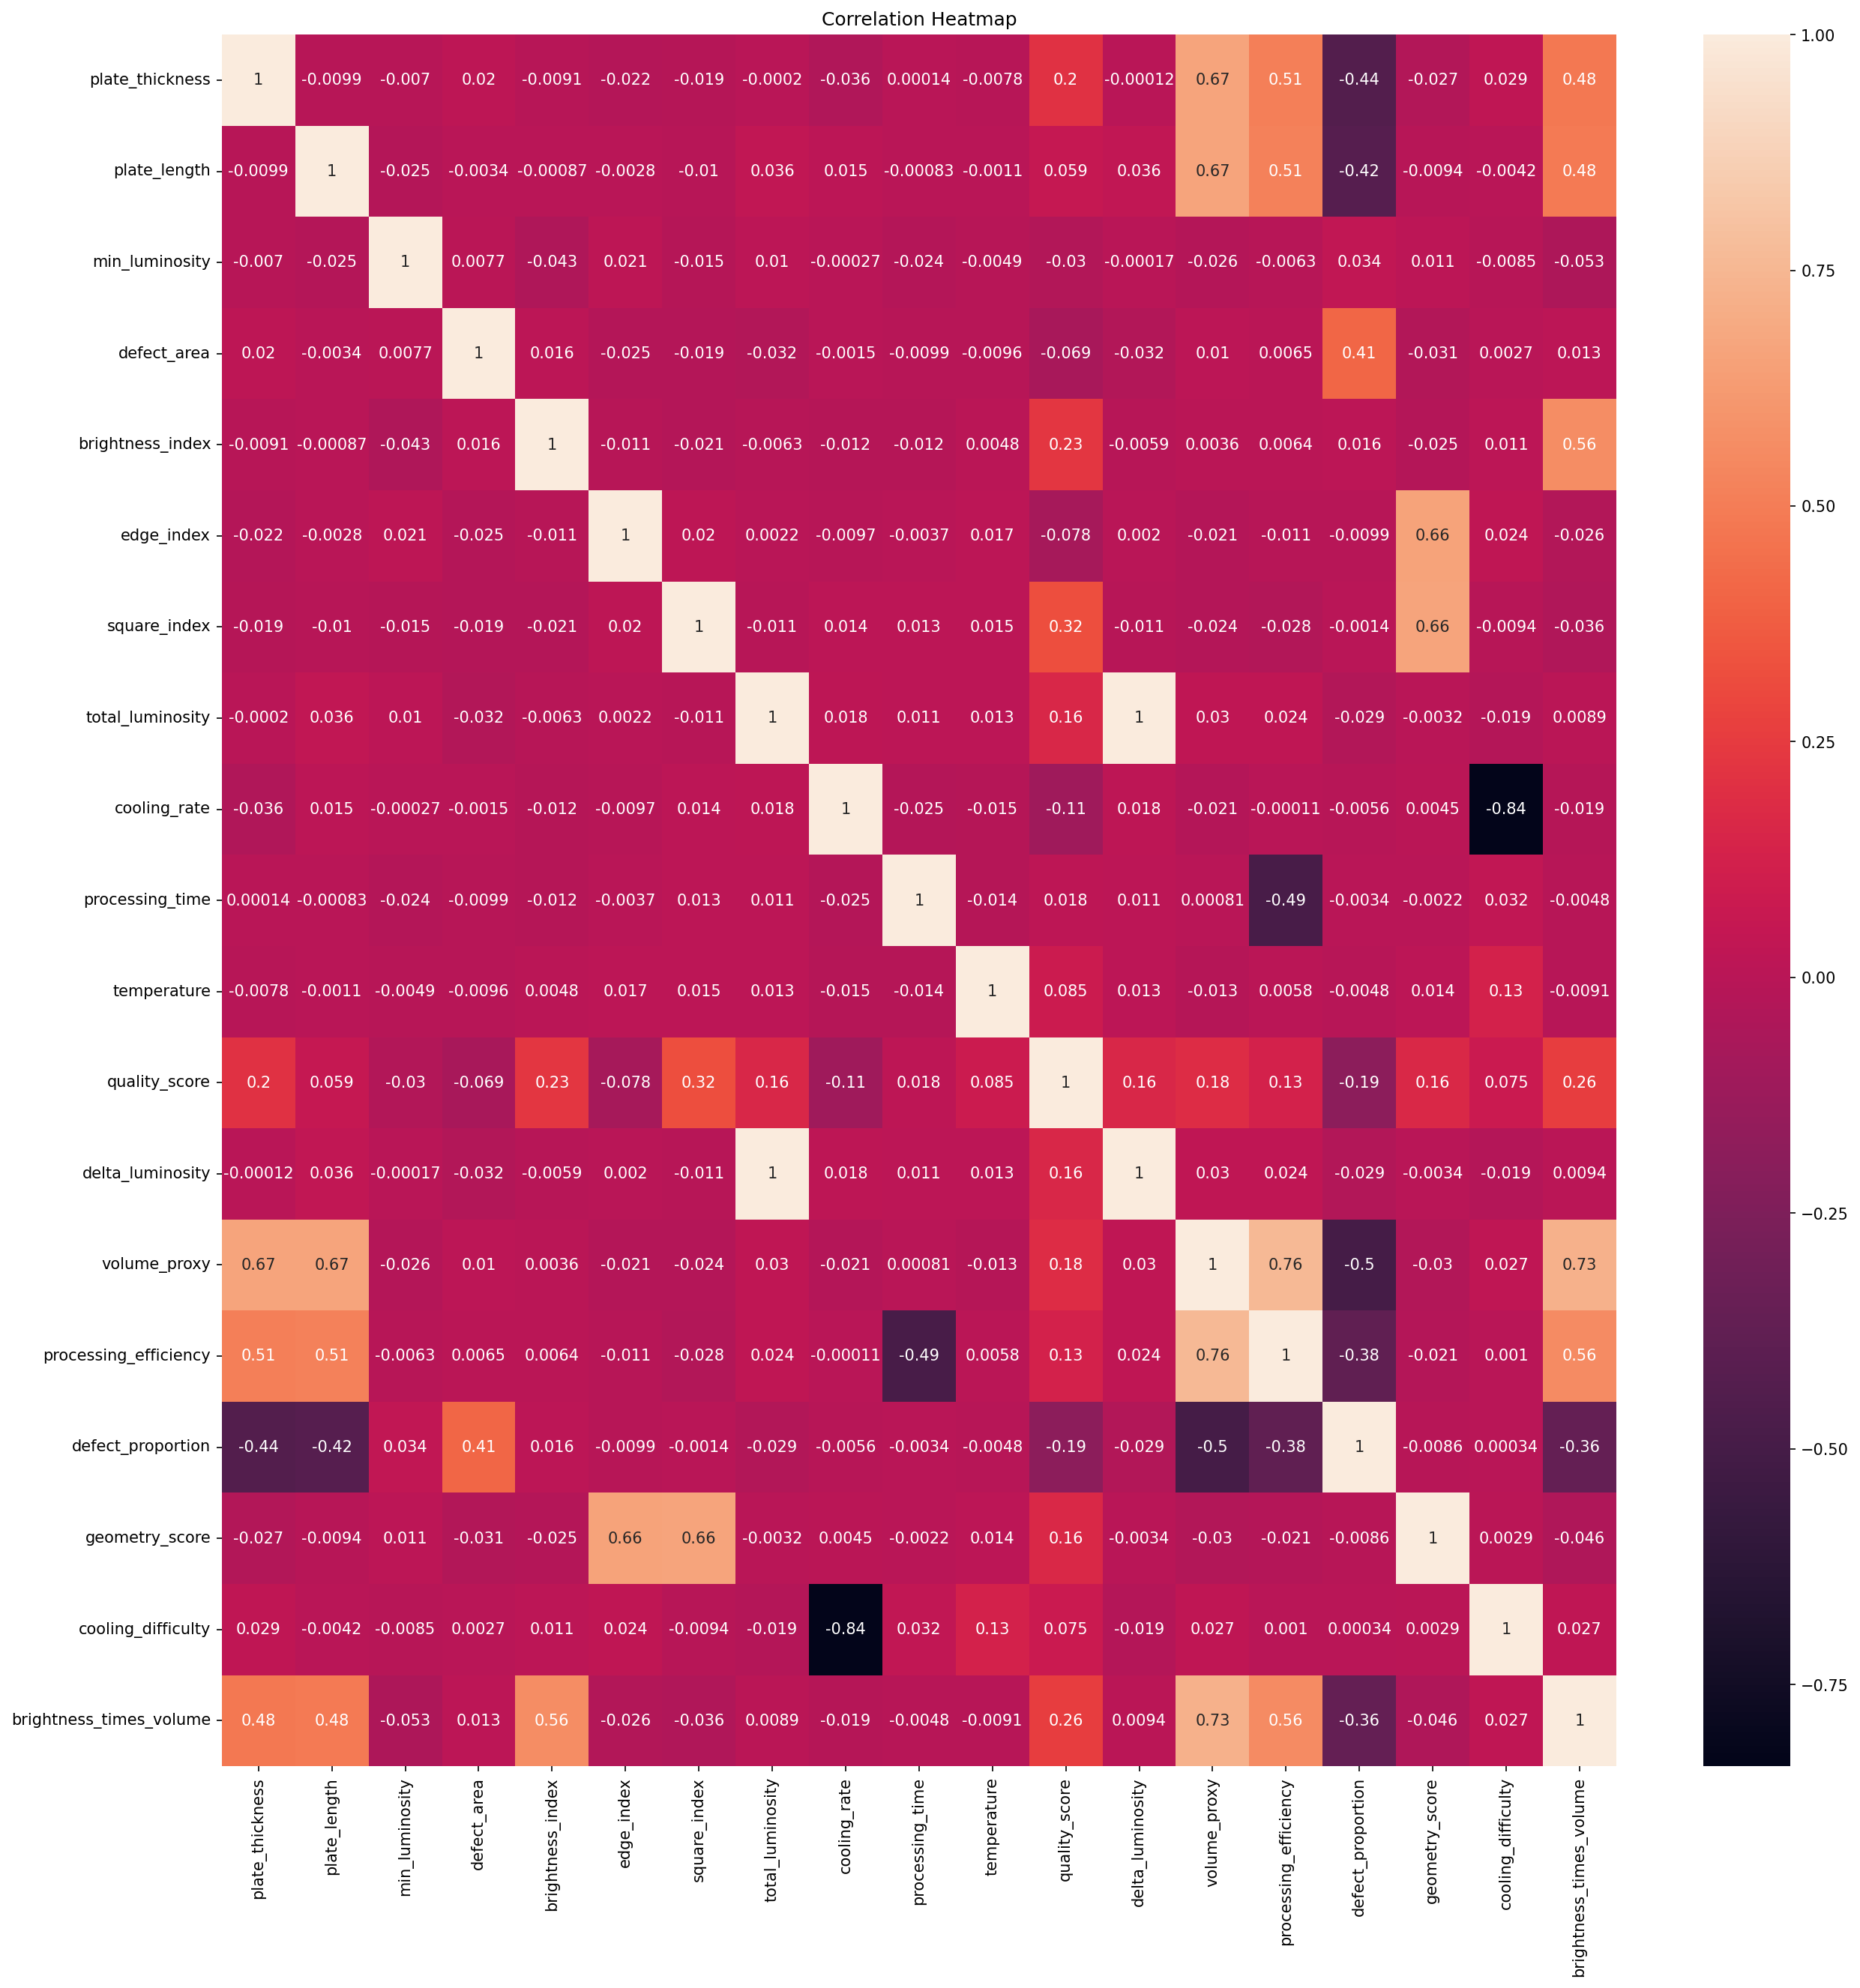

In [13]:
correlations_after_eng = train_for_eng.drop("day", "month", "hour", "machine_id", "operator_id").to_pandas().corr()

plt.figure(figsize=(20, 20))

sns.heatmap(
    correlations_after_eng,
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

With the new features created, we observe multiple instances of multicolinearity between variables. Even though this does not affect the performance of tree based models, it may affect its interpretability, because the tree may choose one of multiple possible variables to split on that yield similar results but it's not the best choice necessarily because of THAT variable, but of another colinear with it. We will first allow it, then change accordingly

train_for_eng contains, so far, featured engineered variables, some original features dropped ("production_date", "production_time", "id"), no categories encoded

## Dataset for Trees, Multicolinear, Label Encoded, No much selection

In [15]:
label_encoded_train = train_for_eng.with_columns(
    pl.col("machine_id").cast(pl.Categorical).to_physical()
)

label_encoded_train.head(3)

plate_thickness,plate_length,min_luminosity,defect_area,brightness_index,edge_index,square_index,total_luminosity,cooling_rate,processing_time,temperature,quality_score,operator_id,machine_id,hour,month,day,delta_luminosity,volume_proxy,processing_efficiency,defect_proportion,geometry_score,cooling_difficulty,brightness_times_volume
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,u32,i8,i8,i8,f64,f64,f64,f64,f64,f64,f64
4.370861,45.427197,3.736408,24.983512,7.299983,0.461854,6.381446,628.922999,18.451042,231.972962,1923.618289,0.705741,38,0,5,11,30,625.186591,198.555966,0.855944,0.125826,2.947297,104.255267,1449.455199
9.556429,52.609209,3.329121,37.337339,1.84512,0.303769,4.592925,86.958294,9.2668,426.695368,1747.258522,0.778742,39,1,11,11,24,83.629173,502.756161,1.178255,0.074265,1.395186,188.550367,927.645426
7.587945,86.909265,1.761539,28.133339,3.466397,3.02096,9.644985,631.647324,10.686165,497.750727,1597.732805,0.78214,17,2,6,2,14,629.885785,659.462767,1.324886,0.042661,29.137112,149.514142,2285.959721


In [16]:
label_encoded_train.write_csv(DATA_PATH + "label_encoded_feat_eng.csv")

## One-Hot Encoded for Neural Nets and Linear Regression

In [18]:
one_hot_encoded_df = train_for_eng.to_dummies(["machine_id", "operator_id", "hour", "month", "day"])
one_hot_encoded_df

plate_thickness,plate_length,min_luminosity,defect_area,brightness_index,edge_index,square_index,total_luminosity,cooling_rate,processing_time,temperature,quality_score,operator_id_1,operator_id_10,operator_id_11,operator_id_12,operator_id_13,operator_id_14,operator_id_15,operator_id_16,operator_id_17,operator_id_18,operator_id_19,operator_id_2,operator_id_20,operator_id_21,operator_id_22,operator_id_23,operator_id_24,operator_id_25,operator_id_26,operator_id_27,operator_id_28,operator_id_29,operator_id_3,operator_id_30,operator_id_31,…,day_10,day_11,day_12,day_13,day_14,day_15,day_16,day_17,day_18,day_19,day_2,day_20,day_21,day_22,day_23,day_24,day_25,day_26,day_27,day_28,day_29,day_3,day_30,day_31,day_4,day_5,day_6,day_7,day_8,day_9,delta_luminosity,volume_proxy,processing_efficiency,defect_proportion,geometry_score,cooling_difficulty,brightness_times_volume
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,…,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,f64,f64,f64,f64,f64,f64,f64
4.370861,45.427197,3.736408,24.983512,7.299983,0.461854,6.381446,628.922999,18.451042,231.972962,1923.618289,0.705741,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,625.186591,198.555966,0.855944,0.125826,2.947297,104.255267,1449.455199
9.556429,52.609209,3.329121,37.337339,1.84512,0.303769,4.592925,86.958294,9.2668,426.695368,1747.258522,0.778742,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,83.629173,502.756161,1.178255,0.074265,1.395186,188.550367,927.645426
7.587945,86.909265,1.761539,28.133339,3.466397,3.02096,9.644985,631.647324,10.686165,497.750727,1597.732805,0.78214,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,629.885785,659.462767,1.324886,0.042661,29.137112,149.514142,2285.959721
6.387926,40.600395,6.072667,4.165129,6.632806,4.830582,2.189785,135.185176,13.130201,436.304615,1868.320893,0.788625,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,129.11251,259.352332,0.594429,0.01606,10.577933,142.291876,1720.233798
2.404168,88.268472,4.766242,9.279012,4.820893,2.513607,5.878564,724.827027,14.1644,238.457171,1709.339068,0.855248,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,720.060785,212.212214,0.889938,0.043725,14.776397,120.678536,1023.052472
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
4.978963,56.343655,4.243381,2.995235,9.133047,3.336035,7.758606,242.571726,27.314133,374.784975,1762.254422,0.874097,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,238.328344,280.532989,0.748517,0.010677,25.882982,64.518044,2562.121016
4.009611,24.883338,9.156914,11.372906,4.284731,1.252532,7.507792,917.745042,24.067627,468.851047,1731.907802,0.664872,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,908.588129,99.772497,0.212802,0.113988,9.403749,71.960057,427.49831
4.551151,97.994153,4.979381,12.969,3.77866,4.065724,3.209786,767.732673,7.167559,256.740413,1970.230097,0.660647,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,762.753292,445.986172,1.737109,0.029079,13.050104,274.881618,1685.230072


In [ ]:
one_hot_encoded_df.write_csv(DATA_PATH + "one_hot_encoded.csv")

: 

: 

: 

: 

: 